## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Loading and Viewing the Dataset

In [2]:
# creating a variable to store the absolute .csv file path for the full Reaxys dataset ("no_numbers" = no Reaxys registry numbers as final column)
reaxys_path = r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/reaxys_dataset/reaxys_data_no_numbers.csv'

# reading in the dataset as stored in the path variable
reaxys = pd.read_csv(reaxys_path)

# printing the index and heading of each column in the dataset
for i, col in enumerate(reaxys.columns):
    print(i, repr(col))

# viewing the shape (no. entries) and title of columns contained by the data
print('Shape:', reaxys.shape)
print('\nColumns:')
for col in reaxys.columns:
    print(repr(col))

# checking for missing values within the dataset
print('\nMissing values:')
print(reaxys.isnull().sum())

0 'Chromophore'
1 'Solvent'
2 'Absorption max (nm)'
3 'log(e/mol-1 dm3 cm-1)'
Shape: (55866, 4)

Columns:
'Chromophore'
'Solvent'
'Absorption max (nm)'
'log(e/mol-1 dm3 cm-1)'

Missing values:
Chromophore              0
Solvent                  0
Absorption max (nm)      0
log(e/mol-1 dm3 cm-1)    0
dtype: int64


#### Comments:
55,866 datapoints in Reaxys representing ~38k chromophores as reported

No missing values in dataset => handy for later analysis

## **Google-Colab-Based Replication**

## Reproducing Figure 2 - Prediction Analysis

In [3]:
# loading test Reaxys dataset and Chemprop predictions obtained utilising the Google Colab
test = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/reaxys_test_filtered_no_reg_nums.csv')
preds = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/colab_reaxys/table1_reaxys_test_preds_filtered.csv')

In [6]:
# specifying columns within the ensemble/individual prediction outputs file which are related to wavelength and log(molar extinction coefficient),
# respectively
wavelength_cols = [c for c in preds.columns if 'Absorption max (nm)_model_' in c]
log_cols = [c for c in preds.columns if 'log(e/mol-1 dm3 cm-1)_model_' in c]

# converting string values to numeric (float) values for both predicted target properties' columns
preds['Absorption max (nm)'] = (preds[wavelength_cols].astype(float).mean(axis=1))
preds['log(e/mol-1 dm3 cm-1)'] = (preds[log_cols].astype(float).mean(axis=1))

In [9]:
# creating lists to store evaluation metrics for predicted wavelength values
wavelength_rmse = []
wavelength_mae = []

# creating lists to store evaluation metrics for predicted log(molar extinction coefficient) values
log_mec_rmse = []
log_mec_mae = []

# iterating through prediction files
for i in range(5):
    # splitting predicted values for both targets into separate variables
    pred_wavelength = preds[f'Absorption max (nm)_model_{i}']
    pred_log_mec = preds[f'log(e/mol-1 dm3 cm-1)_model_{i}']

    # removing rows where prediction failed and keeping valid rows only
    valid_preds = (preds['Absorption max (nm)'].notna() & preds['log(e/mol-1 dm3 cm-1)'].notna())
    
    # splitting valid true values for wavelength and log(molar extinction coefficient) into separate variables
    true_wavelength = test.loc[valid_preds, 'Absorption max (nm)']
    true_log_mec = test.loc[valid_preds, 'log(e/mol-1 dm3 cm-1)']

    # calculating evaluation metrics for wavelength into separate lists
    wavelength_rmse.append(np.sqrt(mean_squared_error(true_wavelength, pred_wavelength)))
    wavelength_mae.append(mean_absolute_error(true_wavelength, pred_wavelength))

    # calculating evaluation metrics for log(molar extinction coefficient) into separate lists
    log_mec_rmse.append(np.sqrt(mean_squared_error(true_log_mec, pred_log_mec)))
    log_mec_mae.append(mean_absolute_error(true_log_mec, pred_log_mec))

# calculating (ensemble) evaluation metrics for wavelength across all 5 models
ensemble_wavelength_rmse = np.sqrt(mean_squared_error(true_wavelength, preds['Absorption max (nm)']))
ensemble_wavelength_mae = mean_absolute_error(true_wavelength, preds['Absorption max (nm)'])

# calculating (ensemble) evaluation metrics for log(molar extinction coefficient) across all 5 models
ensemble_log_mec_rmse = np.sqrt(mean_squared_error(true_log_mec, preds['log(e/mol-1 dm3 cm-1)']))
ensemble_log_mec_mae = mean_absolute_error(true_log_mec, preds['log(e/mol-1 dm3 cm-1)'])

# calculating (ensemble) standard deviations for both wavelength error metrics across all models
ensemble_wavelength_rmse_sd = np.std(wavelength_rmse)
ensemble_wavelength_mae_sd = np.std(wavelength_mae)

# calculating (ensemble) standard deviations for both log(molar extinction coefficient) error metrics across all models
ensemble_log_mec_rmse_sd = np.std(log_mec_rmse)
ensemble_log_mec_mae_sd = np.std(log_mec_mae)

In [10]:
# printing evaluation metrics for both target properties
print('Reaxys Wavelength RMSE:', ensemble_wavelength_rmse, '+/-', ensemble_wavelength_rmse_sd)
print('Reaxys Wavelength MAE:', ensemble_wavelength_mae, '+/-', ensemble_wavelength_mae_sd)

print('\nReaxys Log(molar extinction coefficient) RMSE:', ensemble_log_mec_rmse, '+/-', ensemble_log_mec_rmse_sd)
print('Reaxys Log(molar extinction coefficient) MAE:', ensemble_log_mec_mae,'+/-', ensemble_log_mec_mae_sd)

Reaxys Wavelength RMSE: 38.30768962614079 +/- 0.25336760193466346
Reaxys Wavelength MAE: 20.89860949725671 +/- 0.1492525374389018

Reaxys Log(molar extinction coefficient) RMSE: 0.3897347307068674 +/- 0.001942484312875581
Reaxys Log(molar extinction coefficient) MAE: 0.22666720191884196 +/- 0.0008506184064340353


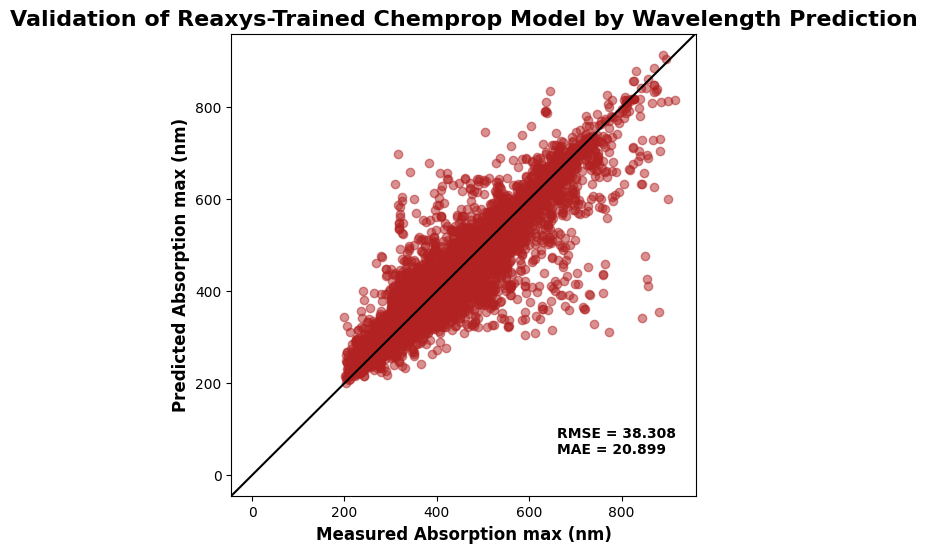

In [12]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(true_wavelength, pred_wavelength, alpha=0.5, color='firebrick')

# adding ideal prediction line (r^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Reaxys-Trained Chemprop Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained ensemble evaluation metric values (excluding SDs)
plt.text(0.70, 0.15, f'RMSE = {ensemble_wavelength_rmse:.3f}\nMAE = {ensemble_wavelength_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

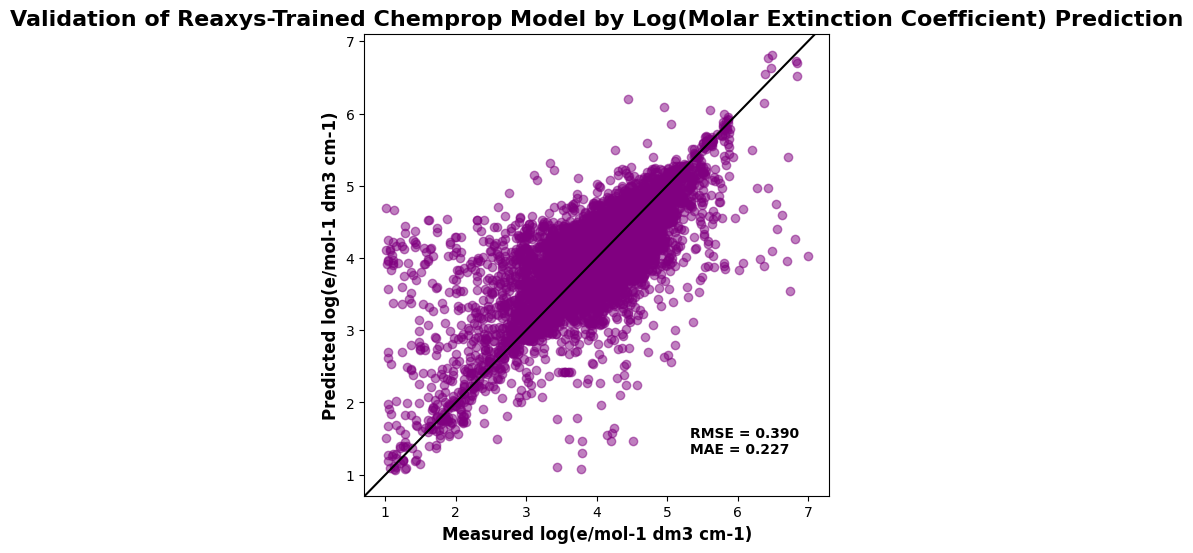

In [13]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(true_log_mec, pred_log_mec, alpha=0.5, color='purple')

# adding ideal prediction line (r^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Reaxys-Trained Chemprop Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained ensemble evaluation metric values (excluding SDs)
plt.text(0.70, 0.15, f'RMSE = {ensemble_log_mec_rmse:.3f}\nMAE = {ensemble_log_mec_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()